# Prédiction du prix de l'immobilier — Modèle M4
### XGBoost · Target Encoding · Optimisation Optuna

Ce notebook met en œuvre un modèle de régression pour prédire le prix de vente de maisons (jeu de données *House Prices*, Kaggle). L'approche s'articule autour de trois piliers :

1. un **feature engineering** orienté métier — gestion fine des valeurs manquantes et création de variables agrégées ;
2. un **prétraitement sans fuite de données**, reconstruit à chaque pli de validation croisée ;
3. une **optimisation bayésienne des hyperparamètres** avec Optuna et arrêt anticipé.

La cible `SalePrice` est modélisée en échelle logarithmique afin d'optimiser directement le **RMSLE**, la métrique officielle du concours.

---

**Sommaire**

| Étape | Contenu |
|---|---|
| 1 | Importations |
| 2 | Feature engineering |
| 3 | Prétraitement *(preprocessor)* |
| 4 | Optimisation des hyperparamètres *(Optuna)* |
| 5 | Modèle final |
| 6 | Soumission Kaggle |
| 7 | Évaluation finale |

> **Dépendances** : `pip install xgboost optuna category_encoders scikit-learn matplotlib seaborn`

## 1. Importations

Chargement des bibliothèques. `category_encoders` fournit le **Target Encoder**, `xgboost` le modèle de gradient boosting, et `optuna` le moteur d'optimisation des hyperparamètres.

In [15]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

from category_encoders import TargetEncoder
from xgboost import XGBRegressor
import optuna

## 2. Feature engineering

Toutes les transformations de cette étape sont **déterministes** : elles n'utilisent jamais la cible, et peuvent donc être appliquées à l'identique au train et au test, sans risque de fuite de données. La fonction `feature_engineering` enchaîne six opérations :

- **A — Surfaces absentes → 0.** Une surface de garage ou de sous-sol manquante traduit l'absence de l'équipement, pas une donnée inconnue.
- **B — Année du garage.** Valeur manquante remplacée par l'année de construction ; une erreur de saisie (année postérieure à la vente) est corrigée.
- **C — Encodage ordinal des qualités.** Les notes `Ex > Gd > TA > Fa > Po` deviennent des entiers ordonnés. On distingue les équipements *pouvant être absents* (manquant → `0`) de ceux *toujours présents* (manquant → valeur typique `3`).
- **D — Variables agrégées.** Surface totale, nombre de salles de bain, surfaces extérieures, interaction *qualité × surface*, et indicateurs de présence (`Has*`).
- **E — Âges.** Plus parlants que les années brutes, et bornés à `0`.
- **F — Catégories absentes → `'None'`.** Un manquant y signifie l'absence de l'élément (pas d'allée, pas de clôture…).

En complément, les **deux maisons aberrantes** (très grandes, vendues à bas prix) sont retirées du train, et la cible est transformée par `log1p`.

> **Pourquoi le logarithme de la cible ?** Les prix varient de façon *multiplicative* : une erreur de 10 % a le même poids à 100 k\$ ou à 500 k\$. Entraîner sur `log(prix)` revient à minimiser l'erreur **relative**, ce qui correspond exactement au RMSLE noté par Kaggle, tout en réduisant l'influence des maisons les plus chères.

In [16]:
def feature_engineering(data):

    df = data.copy()

    # MSSubClass est un code de type de logement, pas une quantité -> catégoriel
    df['MSSubClass'] = df['MSSubClass'].astype(str)

    # A. Surfaces / compteurs absents -> 0
    zero_fill = ['MasVnrArea', 'GarageArea', 'GarageCars', 'TotalBsmtSF',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath']
    for c in zero_fill:
        if c in df.columns:
            df[c] = df[c].fillna(0)

    # B. Année du garage : manquante -> année de construction ;
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
    df['GarageYrBlt'] = df['GarageYrBlt'].clip(upper=df['YrSold'])

    # C. Encodage ordinal des qualités (Po < Fa < TA < Gd < Ex)
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    for c in ['BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(0)
    for c in ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual']:
        if c in df.columns:
            df[c] = df[c].map(qual_map).fillna(3)

    df['BsmtExposure'] = df['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}).fillna(0)
    fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
    df['BsmtFinType1'] = df['BsmtFinType1'].map(fin_map).fillna(0)
    df['BsmtFinType2'] = df['BsmtFinType2'].map(fin_map).fillna(0)
    df['GarageFinish'] = df['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}).fillna(0)
    df['Functional'] = df['Functional'].map(
        {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}).fillna(7)

    # D. Nouvelles variables (agrégats + interaction)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch']
                          + df['ScreenPorch'] + df['WoodDeckSF'])
    df['QualxArea'] = df['OverallQual'] * df['GrLivArea']
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)

    # E. Âges (bornés à 0)
    df['AgeBuilt'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
    df['AgeRemodAdd'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)
    df['AgeGarage'] = (df['YrSold'] - df['GarageYrBlt']).clip(lower=0)
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

    # F. Catégories absentes -> 'None'
    for c in ['Alley', 'Fence', 'MiscFeature', 'GarageType', 'MasVnrType']:
        if c in df.columns:
            df[c] = df[c].fillna('None')

    return df


# Chargement des données
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Suppression des 2 outliers (uniquement sur le train)
train_df = train_df.drop(train_df[train_df['GrLivArea'] > 4000].index)

# Feature engineering
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

# Séparation X / y (cible transformée par log1p)
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (1456, 88) | X_test : (1459, 88)


## 3. Prétraitement

Le *preprocessor* applique deux traitements en parallèle selon le type de colonne :

- **Numériques** → imputation par la **médiane**. Aucun *scaling* : un modèle d'arbres est insensible à l'échelle des variables.
- **Catégorielles** → imputation par le mode, puis **Target Encoding** : chaque modalité est remplacée par la moyenne (lissée) de la cible pour cette modalité. Le paramètre `smoothing=10` protège les catégories rares en les ramenant vers la moyenne globale.

Point clé : le preprocessor est encapsulé dans une **fonction**, afin d'en reconstruire un exemplaire neuf à chaque pli de validation. Le Target Encoding n'apprend ainsi jamais sur les données qu'il devra prédire — c'est la garantie contre la **fuite de données** *(data leakage)*.

In [17]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numériques :", len(numeric_features), "| Catégorielles (Target Encoding) :", len(categorical_features))


def build_preprocessor():
    """Reconstruit un preprocessor neuf (réajusté par pli -> pas de fuite de données)."""
    num_t = SimpleImputer(strategy='median')

    cat_t = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value'))
    ])

    return ColumnTransformer(transformers=[
        ('num', num_t, numeric_features),
        ('cat', cat_t, categorical_features),
    ])

Numériques : 59 | Catégorielles (Target Encoding) : 29


## 4. Optimisation des hyperparamètres *(Optuna)*

Optuna recherche la meilleure combinaison d'hyperparamètres par **optimisation bayésienne** : contrairement à une recherche exhaustive, il exploite ses essais passés pour cibler les zones prometteuses. Chaque configuration est évaluée par **validation croisée à 5 plis**, avec un **arrêt anticipé** *(early stopping)* qui détermine automatiquement le nombre d'arbres optimal.

L'échantillonneur `TPESampler` est initialisé avec une graine fixe (`seed=42`), ce qui rend la recherche entièrement **reproductible**.

**Espace de recherche exploré :**

| Hyperparamètre | Rôle | Plage |
|---|---|---|
| `max_depth` | profondeur des arbres (complexité) | 2 – 6 |
| `min_child_weight` | poids minimal pour scinder un nœud (anti-surapprentissage) | 3 – 10 |
| `learning_rate` | vitesse d'apprentissage | 0.005 – 0.05 |
| `subsample` | part des lignes utilisées par arbre | 0.5 – 0.9 |
| `colsample_bytree` | part des variables utilisées par arbre | 0.4 – 0.8 |
| `reg_alpha` | régularisation L1 *(Lasso)* | 0.01 – 10 |
| `reg_lambda` | régularisation L2 *(Ridge)* | 0.01 – 10 |

In [18]:
import time

start_global_time = time.time()

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_SPLITS = 5


def cross_validate(params, return_iters=False):
    """Évalue une configuration par validation croisée KFold (RMSE moyen, échelle log)."""
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    rmses, best_iters = [], []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        # Preprocessor neuf par pli -> pas de fuite vers le set de validation
        pre = build_preprocessor()
        X_tr_t = pre.fit_transform(X_tr, y_tr)
        X_val_t = pre.transform(X_val)

        model = XGBRegressor(
            n_estimators=3000,
            early_stopping_rounds=50,
            tree_method='hist',
            random_state=42, n_jobs=-1,
            **params
        )
        model.fit(X_tr_t, y_tr, eval_set=[(X_val_t, y_val)], verbose=False)

        val_preds = model.predict(X_val_t)
        rmses.append(np.sqrt(mean_squared_error(y_val, val_preds)))
        best_iters.append(model.best_iteration)

    if return_iters:
        return np.mean(rmses), np.mean(best_iters)
    return np.mean(rmses)


def objective(trial):
    """Espace de recherche des hyperparamètres exploré par Optuna."""
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
    }
    return cross_validate(params)


print("Lancement d'Optuna...")
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=80, show_progress_bar=True)

print("\n--- RÉSULTATS ---")
print(f"Meilleur RMSE (CV, échelle log) : {study.best_value:.5f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Lancement d'Optuna...


Best trial: 48. Best value: 0.112753: 100%|██████████| 80/80 [06:59<00:00,  5.25s/it]


--- RÉSULTATS ---
Meilleur RMSE (CV, échelle log) : 0.11275
  max_depth: 4
  min_child_weight: 5
  learning_rate: 0.022458876023846695
  subsample: 0.5023147510645035
  colsample_bytree: 0.4901429374583633
  reg_alpha: 0.11544066323643319
  reg_lambda: 0.0286912028778077


## 5. Modèle final

On récupère le nombre d'arbres optimal moyen observé en validation croisée, **majoré de 10 %**. Raison : le modèle final s'entraîne désormais sur **100 %** du jeu d'entraînement (contre 80 % dans chaque pli de validation), il a donc besoin d'un peu plus d'arbres pour exploiter ces données supplémentaires sans sur-apprendre.

Le preprocessor est ajusté une dernière fois sur l'ensemble du train, puis le modèle est entraîné avec la meilleure configuration trouvée.

In [19]:
best_params = study.best_params

# Nombre d'arbres optimal moyen observé en validation croisée (+10 % car on entraîne sur 100 % des données)
_, avg_best_iter = cross_validate(best_params, return_iters=True)
final_n_estimators = int(avg_best_iter * 1.1)
print(f"n_estimators retenu : {final_n_estimators}")

final_preprocessor = build_preprocessor()
X_train_t = final_preprocessor.fit_transform(X_train, y_train)

final_model = XGBRegressor(
    n_estimators=final_n_estimators,
    tree_method='hist',
    random_state=42, n_jobs=-1,
    **best_params
)
final_model.fit(X_train_t, y_train)
print("Modèle final entraîné.")

global_training_time = time.time() - start_global_time

n_estimators retenu : 538
Modèle final entraîné.


## 6. Soumission Kaggle

La transformation apprise sur le train est appliquée au test. Le modèle prédisant en échelle logarithmique, on utilise `np.expm1` — la fonction **inverse** de `log1p` — pour reconvertir les prédictions en dollars, avant l'export au format attendu par Kaggle (`Id`, `SalePrice`).

In [20]:
X_test_t = final_preprocessor.transform(X_test)

# Le modèle prédit en échelle log : expm1 reconvertit en dollars
final_predictions = np.expm1(final_model.predict(X_test_t))

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_predictions})

fichier = 'submission_M4_XGBoost_Optuna.csv'
submission.to_csv(fichier, index=False)
print(f"Fichier '{fichier}' prêt à soumettre.")
submission.head()

Fichier 'submission_M4_XGBoost_Optuna.csv' prêt à soumettre.


,Id,SalePrice
0,1461,121998.820312
1,1462,159912.218750
2,1463,181412.265625
3,1464,190673.000000
4,1465,190348.500000


## 7. Évaluation finale

Le modèle est évalué selon les **trois critères** retenus par le groupe :

- **Mathématique — RMSE.** RMSE moyen de validation croisée sur l'échelle logarithmique, issu de l'optimisation Optuna.
- **IT — Temps d'entraînement.** Durée totale, recherche d'hyperparamètres comprise.
- **Métier — Écart médian (%).** Médiane des écarts relatifs entre prix prédit et prix réel, calculée sur des prédictions *out-of-fold* (honnêtes, sans fuite). La médiane est robuste aux valeurs extrêmes et reflète l'erreur **typique** du modèle.

Le graphique final présente les **15 variables les plus importantes** du modèle.

  ÉVALUATION FINALE — MODÈLE M4 XGBOOST
  Mathématique (RMSE Log) : 0.11275
  IT (Temps entraînement) : 426.22 secondes
  Métier (Écart médian)   : 5.46 %


/tmp/ipykernel_204710/3744174216.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')


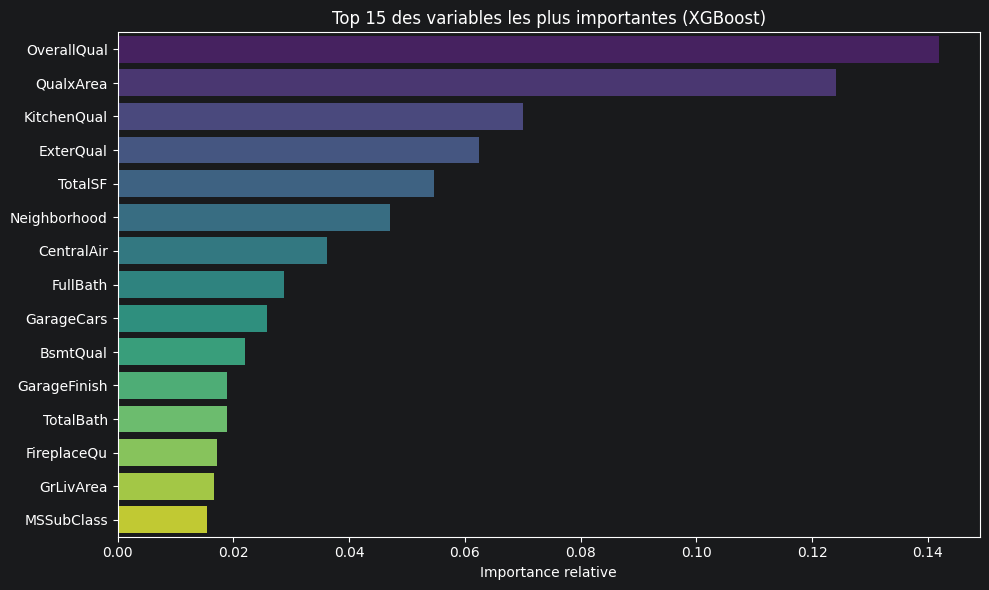

In [21]:
from sklearn.model_selection import cross_val_predict
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mathématique : RMSE (depuis Optuna)
rmse_log = study.best_value

# 2. IT : temps d'entraînement global
train_time = global_training_time

# 3. Métier : % d'écart médian sur prédictions Out-Of-Fold (sans fuite)
kf_eval = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_log = np.zeros(len(X_train))

for train_idx, val_idx in kf_eval.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    pre = build_preprocessor()
    X_tr_t = pre.fit_transform(X_tr, y_tr)
    X_val_t = pre.transform(X_val)

    model_eval = XGBRegressor(
        n_estimators=final_n_estimators,
        tree_method='hist',
        random_state=42, n_jobs=-1,
        **study.best_params
    )
    model_eval.fit(X_tr_t, y_tr)
    oof_pred_log[val_idx] = model_eval.predict(X_val_t)

oof_pred_price = np.expm1(oof_pred_log)
y_train_price = np.expm1(y_train)

ecart_pct = np.abs(oof_pred_price - y_train_price) / y_train_price * 100
ecart_median = np.median(ecart_pct)

# Affichage des trois critères
print("=" * 50)
print("  ÉVALUATION FINALE — MODÈLE M4 XGBOOST")
print("=" * 50)
print(f"  Mathématique (RMSE Log) : {rmse_log:.5f}")
print(f"  IT (Temps entraînement) : {train_time:.2f} secondes")
print(f"  Métier (Écart médian)   : {ecart_median:.2f} %")
print("=" * 50)

# Graphique : importance des variables (Top 15)
feature_names = numeric_features + categorical_features
importances = final_model.feature_importances_

importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Variable', palette='viridis')
plt.title('Top 15 des variables les plus importantes (XGBoost)')
plt.xlabel('Importance relative')
plt.ylabel('')
plt.tight_layout()
plt.show()